# CAR PRICE PREDICTION

### DATA PREPERATION

In [1]:
import numpy as np
import pandas as pd

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv'

In [3]:
!wget $data

--2026-06-19 10:27:25--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.1’

data.csv.1          100%[===================>]   1.41M  --.-KB/s    in 0.1s    

2026-06-19 10:27:25 (11.4 MB/s) - ‘data.csv.1’ saved [1475504/1475504]



In [4]:
df = pd.read_csv('data.csv')


In [5]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


Make Data consistent (capital/small letters, space/_)

In [6]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [7]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [8]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


In [9]:

df.dtypes 

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [10]:
df.dtypes == 'str'

make                  True
model                 True
year                 False
engine_fuel_type      True
engine_hp            False
engine_cylinders     False
transmission_type     True
driven_wheels         True
number_of_doors      False
market_category       True
vehicle_size          True
vehicle_style         True
highway_mpg          False
city_mpg             False
popularity           False
msrp                 False
dtype: bool

In [11]:

df.dtypes[df.dtypes == 'str']

# INDEX          Values

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [12]:
list(df.dtypes[df.dtypes == 'str'].index)
#  Simply cuz lists look cleaner

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [13]:
strings = (list(df.dtypes[df.dtypes == 'str'].index))
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [14]:
for cols in strings:
    df[cols] = df[cols].str.lower().str.replace(' ', '_')

In [15]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


Exploratory data analysis:

In [16]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

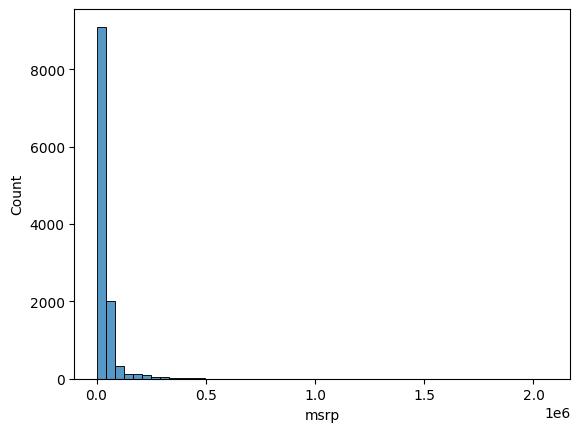

In [18]:
sns.histplot(df.msrp, bins=50)
# msrp distribution(long tail)


<Axes: xlabel='msrp', ylabel='Count'>

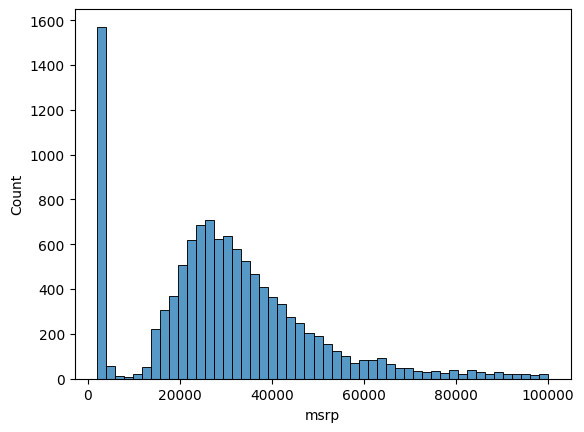

In [19]:
sns.histplot(df.msrp[df.msrp<100000], bins=50)

In [20]:
np.log([0+1, 1+1, 10+1, 1000+1, 1000000+1])    # cuz log(0) gives error (inf)
# we'll do this to get rid of long tail.
# The large values stretch the distribution and make learning harder for Linear Regression.

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 13.81551156])

In [21]:
np.log1p([0, 1, 10, 1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [22]:
prices_logs = np.log1p(df.msrp)
prices_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

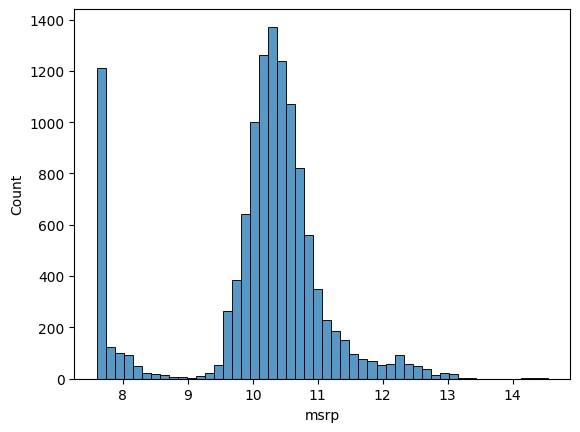

In [23]:
sns.histplot(prices_logs, bins=50)
#  Normally distributed(approx) is ideal for models, avoid long tail distributions

In [24]:
df
# nan == missing values

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [25]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

### Setting validation framework: Train, Validate, test (3:1:1)

In [26]:

n=len(df)
n_val=int(len(df) * 0.2)
n_test=int(len(df) * 0.2)
n_train = n - n_val - n_test

In [27]:
n_val,n_test,n_train

(2382, 2382, 7150)

In [28]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]
# Data set is sequential (all BMW/porche together), we need mixed for more accurate prediction

In [29]:
idx = np.arange(n)

In [30]:
np.random.seed(2)
np.random.shuffle(idx)
idx

array([2735, 6720, 5878, ..., 6637, 2575, 7336], shape=(11914,))

In [31]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
1902,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
9334,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
5284,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


In [32]:
df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

In [33]:
len(df_train),len(df_val),len(df_test)

(7150, 2382, 2382)

In [34]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [35]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

## Linear Regression

In [36]:
df_train.iloc[10]


make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [37]:
x = [453, 11, 86]

In [38]:
w0 = 7.17   # w0 == b
w = [0.01, 0.04, 0.002]

In [39]:

def lin_reg(xi):
    n=len(xi)
    pred = w0
    for j in range(n):
        pred = pred + xi[j]*w[j]
    return pred

In [40]:
lin_reg(x)

12.312

In [41]:
np.exp(12.312) - 1

np.float64(222347.2221101062)

In [42]:
np.expm1(12.312)

np.float64(222347.2221101062)

In [43]:
def dot(xi, w):
    n = len(xi)
    res = 0
    for j in range(n):
        res = res + xi[j] * w[j]
    return res

In [44]:

def lin_reg(xi):
    return w0 + dot(xi, w)

In [45]:
w_new = [w0] + w

In [46]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [47]:

def lin_reg(xi):
    xi= [1] + xi
    return dot(xi, w_new)

In [48]:
lin_reg(x)

12.312

In [49]:
x1 = [1, 148, 24, 1385]
x2 = [1, 132, 25, 2031]
x3 = [1, 453, 11, 86]

x = [x1, x2, x3]   
x = np.array(x)     # 2D array / Matrix
x

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [50]:
x.dot(w_new)

array([12.38 , 13.552, 12.312])

In [51]:
def lin_reg(x):
    return x.dot(w_new)

In [52]:
lin_reg(x)

array([12.38 , 13.552, 12.312])

### Training Linear regression model: GRAM matrix = (X^T.X)

In [53]:
x = [[148, 24, 1385],
[132, 25, 2031],
[453, 11, 86],
[152, 34, 1215],
[117, 35, 1891],
[458, 21, 89],
[132, 27, 1185],
[182, 19, 2411],
[443, 21, 82],
]
x = np.array(x)

In [54]:
ones = np.ones(x.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [55]:
list(np.column_stack([ones, x]))

[array([1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03]),
 array([1.000e+00, 1.320e+02, 2.500e+01, 2.031e+03]),
 array([  1., 453.,  11.,  86.]),
 array([1.000e+00, 1.520e+02, 3.400e+01, 1.215e+03]),
 array([1.000e+00, 1.170e+02, 3.500e+01, 1.891e+03]),
 array([  1., 458.,  21.,  89.]),
 array([1.000e+00, 1.320e+02, 2.700e+01, 1.185e+03]),
 array([1.000e+00, 1.820e+02, 1.900e+01, 2.411e+03]),
 array([  1., 443.,  21.,  82.])]

In [56]:

xTx = x.T.dot(x)   # GRAM matrix

In [57]:
xTx_inv = np.linalg.inv(xTx)

In [58]:
xTx.dot(xTx_inv).round(1)

array([[ 1.,  0., -0.],
       [ 0.,  1., -0.],
       [ 0.,  0.,  1.]])

In [59]:
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]

In [60]:
w_full = xTx_inv.dot(x.T).dot(y)
w_full

array([0.30359199, 1.0975731 , 0.05864504])

In [61]:
w0=w_full[0]
w=w_full[1:]

In [62]:
w0, w

(np.float64(0.3035919914901254), array([1.0975731 , 0.05864504]))

In [63]:
def train_w(x, y):
    ones = np.ones(x.shape[0])
    x = np.column_stack([ones, x])
        
    xTx = x.T.dot(x)
    xTx_inv = np.linalg.inv(xTx)
    w_full = xTx_inv.dot(x.T).dot(y)

    return w_full[0], w_full[1:]

In [64]:
train_w(x, y)

(np.float64(5.117999988369495), array([0.29554021, 1.01554655, 0.05767246]))

## Baseline model: 

In [65]:
df_train.columns


Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [66]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [67]:
base = ['engine_hp','engine_cylinders','highway_mpg', 'city_mpg', 'popularity']
df_train[base]

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,148.0,4.0,33,24,1385
1,132.0,4.0,32,25,2031
2,148.0,4.0,37,28,640
3,90.0,4.0,18,16,873
4,385.0,8.0,21,15,5657
...,...,...,...,...,...
7145,300.0,6.0,31,20,3916
7146,210.0,4.0,30,24,873
7147,285.0,6.0,22,17,549
7148,563.0,12.0,21,13,86


In [68]:
x_train = df_train[base].values
x_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

In [69]:
df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [70]:
df_train[base].fillna(0)
x_train = df_train[base].fillna(0)
df_train.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        1
engine_hp              40
engine_cylinders       14
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      2251
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
dtype: int64

In [71]:
train_w(x_train, y_train)

(np.float64(7.927257388069986),
 array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
        -9.06908672e-06]))

In [72]:
w0, w = train_w(x_train, y_train)

In [73]:
y_pred = w0 + x_train.dot(w)

<Axes: ylabel='Count'>

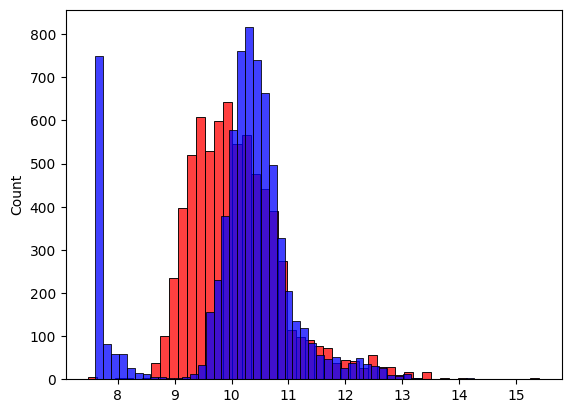

In [74]:
sns.histplot(y_pred, color='red', bins=50)
sns.histplot(y_train, color='blue', bins=50)

## RMSE

In [75]:
def rmse(y, y_pred):
    se = (y-y_pred)**2
    mse = se.mean()
    return np.sqrt(mse)

In [76]:
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

## Validating the model:

In [77]:
base = ['engine_hp','engine_cylinders','highway_mpg', 'city_mpg', 'popularity']


In [78]:
def prepare_x(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    x = df_num.values
    return x

In [79]:
x_train = prepare_x(df_train)
w0, w = train_w(x_train, y_train)

x_val = prepare_x(df_val)
y_pred = w0 + x_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.761653099130156)

## Simple feature engineering:

In [80]:
df_train.year.max()

np.int64(2017)

In [81]:
2017 - df_train.year

0        9
1        5
2        1
3       26
4        0
        ..
7145     2
7146     2
7147     2
7148     3
7149     0
Name: year, Length: 7150, dtype: int64

In [82]:
def prepare_x(df):
    df = df.copy()
    df['age'] = 2017 - df.year
    features = base + ['age']
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    x = df_num.values
    return x

In [83]:
x_train = prepare_x(df_train)

In [84]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [85]:
x_train = prepare_x(df_train)
w0, w = train_w(x_train, y_train)

x_val = prepare_x(df_val)
y_pred = w0 + x_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5172055461058299)

<Axes: ylabel='Count'>

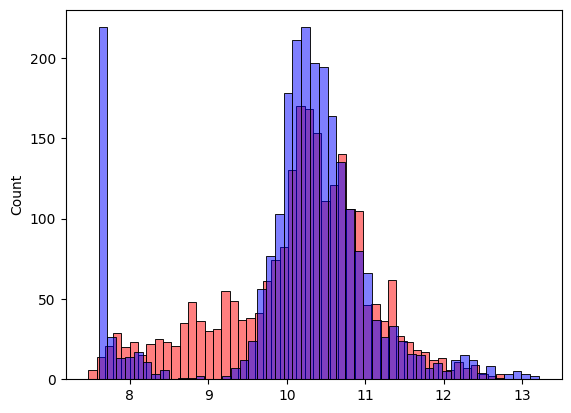

In [86]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5,bins=50)

## Categorical variables:

In [87]:
df_train.number_of_doors      # not numerical although has numbers

0       2.0
1       4.0
2       4.0
3       3.0
4       4.0
       ... 
7145    2.0
7146    2.0
7147    4.0
7148    4.0
7149    4.0
Name: number_of_doors, Length: 7150, dtype: float64

In [88]:
def prepare_x(df):
    df = df.copy()
    features = base.copy()
    df['age'] = 2017 - df.year
    features.append('age')
    
    for v in [2, 3, 4]:
        df['num_doors_%s' %v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' %v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    x = df_num.values
    return x

In [89]:
x_train = prepare_x(df_train)
w0, w = train_w(x_train, y_train)

x_val = prepare_x(df_val)
y_pred = w0 + x_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.515799564150169)

In [90]:
df.make.nunique()

48

In [91]:
makes = list(df.make.value_counts().head().index)

In [92]:
def prepare_x(df):
    df = df.copy()
    features = base.copy()
    
    df['age'] = 2017 - df.year
    features.append('age')
    
    for v in [2, 3, 4]:
        df['num_doors_%s' %v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' %v)

    for v in makes:
            df['make_%s' %v] = (df.make == v).astype('int')
            features.append('make_%s' %v)
            
    df_num = df[features]
    df_num = df_num.fillna(0)
    x = df_num.values
    return x

In [93]:

x_train = prepare_x(df_train)
w0, w = train_w(x_train, y_train)

x_val = prepare_x(df_val)
y_pred = w0 + x_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5076038849556795)

In [94]:
categorical_variables = ['make', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'market_category', 'vehicle_size', 'vehicle_style']

In [95]:
categories = {}

for c in categorical_variables:
    categories[c] = list(df[c].value_counts().head().index)

In [96]:
categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [97]:
def prepare_x(df):
    df = df.copy()
    features = base.copy()
    
    df['age'] = 2017 - df['year']
    features.append('age')
    
    for v in [2, 3, 4]:
        df['num_doors_%s' %v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' %v)

    for c, values in categories.items():
          for v in values:
            df['%s_%s' %(c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' %(c, v))

    for v in makes:
            df['make_%s' %v] = (df.make == v).astype('int')
            features.append('make_%s' %v)
            
    df_num = df[features]
    df_num = df_num.fillna(0)
    x = df_num.values
    return x

In [98]:
x_train = prepare_x(df_train)
w0, w = train_w(x_train, y_train)

x_val = prepare_x(df_val)
y_pred = w0 + x_val.dot(w)

rmse(y_val, y_pred)

np.float64(255.29654994520314)

In [99]:
w0, w

(np.float64(5485010433762953.0),
 array([-6.88576232e-01, -1.15873720e+02, -2.28435823e+01,  5.86128230e+00,
         3.40178444e-02,  4.39295319e+00,  7.59563519e+03,  7.68169401e+03,
         7.61015849e+03,  7.38391600e+02, -4.14118921e+02, -4.03735020e+02,
         3.54993090e+02, -8.19838981e+02, -5.93348560e+02, -5.68946834e+02,
        -5.89037787e+02, -5.63064690e+02, -7.85811521e+02,  3.04114983e+16,
         3.04114983e+16,  3.04114983e+16,  3.04114983e+16,  3.04114983e+16,
        -3.58965088e+16, -3.58965088e+16, -3.58965088e+16, -3.58965088e+16,
        -7.50026298e+00, -2.42841804e+01, -5.81049850e+00, -5.98293472e+00,
        -8.34289637e+01,  1.59228765e+02,  2.03658114e+02,  2.08851997e+02,
        -4.85492239e-02,  5.44797374e-02,  1.78241160e-01,  3.41906701e-01,
        -1.64412078e-01, -6.96965567e+02,  1.16291905e+02,  4.10516709e+02,
        -4.35823365e+02,  6.26841301e+02]))

## Regularization:

In [100]:
x = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5]
]
x = np.array(x)
x

array([[4, 4, 4],
       [3, 5, 5],
       [5, 1, 1],
       [5, 4, 4],
       [7, 5, 5],
       [4, 5, 5]])

In [101]:
xTx = x.T.dot(x)    # In this case inverse does not exist, it is singular
xTx

array([[140, 111, 111],
       [111, 108, 108],
       [111, 108, 108]])

In [102]:
x = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.00000001]
]
x = np.array(x)
x

array([[4.        , 4.        , 4.        ],
       [3.        , 5.        , 5.        ],
       [5.        , 1.        , 1.        ],
       [5.        , 4.        , 4.        ],
       [7.        , 5.        , 5.        ],
       [4.        , 5.        , 5.00000001]])

In [103]:
xTx = x.T.dot(x)       
xTx

array([[140.        , 111.        , 111.00000004],
       [111.        , 108.        , 108.00000005],
       [111.00000004, 108.00000005, 108.0000001 ]])

In [104]:
# xTx_inv = np.linalg.inv(xTx)   error cuz singular matrix
xTx

array([[140.        , 111.        , 111.00000004],
       [111.        , 108.        , 108.00000005],
       [111.00000004, 108.00000005, 108.0000001 ]])

In [105]:
xTx = [
    [1, 2, 2],
    [2, 1, 1.0000001],
    [2, 1, 1]
]

np.array(xTx)

array([[1.       , 2.       , 2.       ],
       [2.       , 1.       , 1.0000001],
       [2.       , 1.       , 1.       ]])

In [106]:
np.linalg.inv(xTx)       # by adding a small number to the diagonal, we can control the values

array([[-3.33333333e-01, -9.31322575e-10,  6.66666667e-01],
       [ 6.66666667e-01, -9.99999999e+06,  9.99999966e+06],
       [-0.00000000e+00,  9.99999999e+06, -9.99999999e+06]])

In [107]:
xTx = xTx + 0.01*np.eye(3)

In [108]:
np.linalg.inv(xTx)

array([[ -0.33668907,   0.33501566,   0.33501231],
       [  0.33501231,  49.91565897, -50.08484019],
       [  0.33501566, -50.08484188,  49.91565897]])

In [109]:
def train_LR_reg(x, y, r=0.001):
    ones = np.ones(x.shape[0])
    x = np.column_stack([ones, x])
        
    xTx = x.T.dot(x)
    xTx = xTx + r*np.eye(xTx.shape[0])

    xTx_inv = np.linalg.inv(xTx)
    w_full = xTx_inv.dot(x.T).dot(y)

    return w_full[0], w_full[1:]

In [110]:
x_train = prepare_x(df_train)
w0, w = train_LR_reg(x_train, y_train, 0.01)

x_val = prepare_x(df_val)
y_pred = w0 + x_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.45652200351370714)

## Tuning the model:

In [111]:
for r in [0, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10]:


    x_train = prepare_x(df_train)
    w0, w = train_LR_reg(x_train, y_train, r)

    x_val = prepare_x(df_val)
    y_pred = w0 + x_val.dot(w)

    score = rmse(y_val, y_pred)

    print(r, w0, score)

0 5485010433762953.0 255.29654994520314
1e-05 6.09626117048354 0.4565170643343183
0.0001 6.330245640833975 0.45651706579969165
0.001 6.285793489134492 0.4565175102492225
0.01 6.276608370161695 0.45652200351370714
0.1 6.191208165354355 0.45656941114127025
1 5.634887405440729 0.45722192577829734
10 4.2838079195210295 0.4701725863391492


In [112]:
r = 0.001
x_train = prepare_x(df_train)
w0, w = train_LR_reg(x_train, y_train, r)
x_val = prepare_x(df_val)
y_pred = w0 + x_val.dot(w)
score = rmse(y_val, y_pred)
score

np.float64(0.4565175102492225)

### Using the model:

In [113]:
df_full_train = pd.concat([df_train, df_val])
df_full_train=df_full_train.reset_index(drop=True)

In [114]:
x_full_train = prepare_x(df_full_train)
x_full_train

array([[148.,   4.,  33., ...,   0.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   1.,   0.],
       [148.,   4.,  37., ...,   0.,   0.,   0.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 46))

In [116]:
y_full_train = np.concatenate([y_train, y_val])

In [117]:

w0, w = train_LR_reg(x_full_train, y_full_train, 0.001)

In [118]:
x_test = prepare_x(df_test)
y_pred = w0 + x_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.451774930467216)

In [121]:
car = df_test.iloc[20].to_dict()
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [122]:
df_small = pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,toyota,sienna,2015,regular_unleaded,266.0,6.0,automatic,front_wheel_drive,4.0,NaN,large,passenger_minivan,25,18,2031


In [125]:
x_small = prepare_x(df_small)

In [128]:
y_pred = w0 + x_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(10.462651609562446)

In [129]:
np.expm1(y_pred)

np.float64(34983.192988707924)

In [131]:
np.expm1(y_test[20])

np.float64(35000.00000000001)